In [1]:
import sys, os
ROOT_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
if ROOT_DIR not in sys.path:
    sys.path.insert(0, ROOT_DIR)
import json
import os
from PIL import Image
import torch
from transformers import AutoProcessor, AutoModelForImageTextToText
from utils.img_utils import resize_long_edge
from utils.caption_utils import scene_generate_v2, scene_generate

from nuscenes.nuscenes import NuScenes
from data.nuscenes_data import NuscenesData
from pathlib import Path

import numpy as np
from IPython.display import display, Markdown
import matplotlib.pyplot as plt
import re

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


## Load VLM (Qwen3-VL) model

In [2]:
model_id = "Qwen/Qwen3-VL-8B-Instruct"
processor = AutoProcessor.from_pretrained(model_id)
model = AutoModelForImageTextToText.from_pretrained(model_id, dtype=torch.bfloat16, device_map="auto")

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

## Load data

In [3]:
# Load dataset
data_path = Path("/home/ximeng/Dataset/nuscenes_full_v1_0/")
nusc = NuScenes(version='v1.0-mini', dataroot=data_path)
is_train = 0 # 0: train, 1: val, 2: test
pre_frame = 4 # 2s
future_frame = 12 # 6s
dataset = NuscenesData(nusc, is_train, pre_frame, future_frame)

Loading NuScenes tables for version v1.0-mini...
23 category,
8 attribute,
4 visibility,
911 instance,
12 sensor,
120 calibrated_sensor,
31206 ego_pose,
8 log,
10 scene,
404 sample,
31206 sample_data,
18538 sample_annotation,
4 map,
Done loading in 0.298 seconds.
Reverse indexing ...
Done reverse indexing in 0.1 seconds.


In [4]:
target_index = 155
sample = dataset[target_index]
token = sample['token']
# Images and LiDAR
raw_images = sample['raw_images']
raw_lidar = sample['raw_lidar']
# Ego state
pre_waypoints = sample['pre_waypoints']
velocity = sample['velocity']
acceleration = sample['accel']
yaw_rate = sample['yaw_rate']
# Ground truth
future_waypoints = sample['future_waypoints']

In [5]:
token

['0915646e387b484785ae2b847ffdee2f']

In [6]:
# Images
print(f"Images shape: {raw_images.shape}")  # [5, 6, 3, 900, 1600]
# Ego state
print(f"pre_waypoints: {pre_waypoints}")
print(f"velocity: {velocity}, acceleration: {acceleration}, yaw_rate: {yaw_rate}")

Images shape: torch.Size([5, 6, 3, 900, 1600])
pre_waypoints: tensor([[-5.1206,  1.2885, -0.3341],
        [-3.8192,  0.8343, -0.3238],
        [-2.5339,  0.4221, -0.2714],
        [-1.2533,  0.1023, -0.1620]])
velocity: tensor([2.5761, 2.6343, 2.5898, 2.5516, 2.6645]), acceleration: tensor([[ 0.5579, -0.2465],
        [-0.0957, -0.0937],
        [-0.2947,  0.3369],
        [-0.2797,  0.6610],
        [ 0.3139,  0.8594]]), yaw_rate: tensor([0.0017, 0.0586, 0.1555, 0.2500, 0.3700])


In [7]:
# Process images
current_images = raw_images[-1]  # [6, 3, H, W]
pil_images = []
for i in range(current_images.shape[0]):
    img_np = current_images[i].permute(1, 2, 0).cpu().numpy() # H, W, 3
    img_pil = Image.fromarray(img_np)
    img_pil = resize_long_edge(img_pil, 512)
    pil_images.append(img_pil)
# Prepare waypoint prompt
pts = pre_waypoints.cpu().numpy().tolist()
wp_strings = [f"({pt[0]:.2f}, {pt[1]:.2f})" for pt in pts]
wp_past = ", ".join(wp_strings)
# Prepare velocity, acceleration, yaw_rate
vel_val = round(velocity[-1].item(), 2)
acc_val = [round(float(a), 2) for a in acceleration[-1]] # [ax, ay]
yr_val = round(yaw_rate[-1].item(), 2)
high_level_command = None  # Placeholder for high-level command

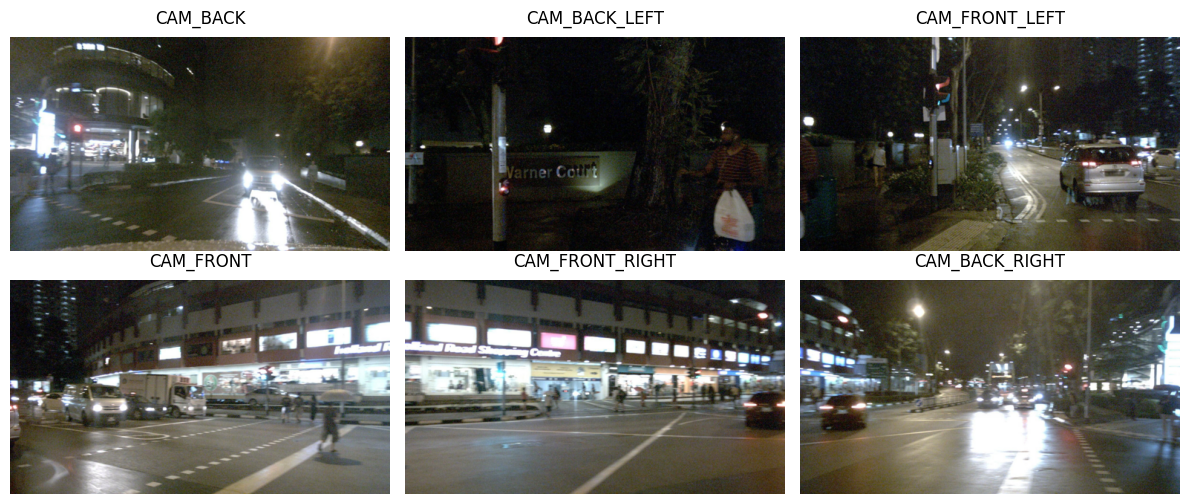

In [8]:
camera_names = ["CAM_BACK", "CAM_BACK_LEFT", "CAM_FRONT_LEFT", "CAM_FRONT", "CAM_FRONT_RIGHT", "CAM_BACK_RIGHT"]

fig, axes = plt.subplots(2, 3, figsize=(12, 8))

for i, ax in enumerate(axes.flat):
    if i < len(pil_images):
        ax.imshow(pil_images[i])
        ax.set_title(camera_names[i], fontsize=12, pad=10)
    ax.axis('off')

plt.tight_layout()
plt.subplots_adjust(top=0.7)
plt.show()

In [9]:
print(wp_past)
print(vel_val, acc_val, yr_val)

(-5.12, 1.29), (-3.82, 0.83), (-2.53, 0.42), (-1.25, 0.10)
2.66 [0.31, 0.86] 0.37


# 

## Navigator (Large VLM)

In [10]:
# System and user prompts
system_prompt = (
    "You are an expert autonomous driving navigator. Your goal is to observe the 360-degree surround-view environment and provide concise, safe driving guidance.\n"
    "Rules:\n"
    "1. Coordinate System: The x-axis positive is forward, the y-axis positive is left.\n"
    "2. Safety Priority: Focus on 'Dynamic Hazards' (pedestrians, moving vehicles) and 'Traffic Regulators' (lights, signs, lane markings).\n"
    "3. Information Filtering: Omit detailed descriptions of static backgrounds or views with no hazards. Only report what affects the immediate driving decision.\n"
    "4. Output Format: Start with a concise 'Perception' summary, followed by 'Action', and a brief 'Reasoning'."
)
ego_status_prompt = (
    "Current Dynamics:\n"
    f"- Velocity: {vel_val:.2f} m/s.\n"
    f"- Yaw Rate: {yr_val:.2f} rad/s.\n"
    f"- Acceleration (Longitudinal x, Lateral y): ({acc_val[0]:.2f}, {acc_val[1]:.2f}) m/s^2.\n"
    f"- Past Trajectory (2Hz): {wp_past} m.\n\n"
    f"High-level Command: {high_level_command}\n"
)
user_prompt = (
    f"Inputs: 6 images (Full Surround View) and Ego-Vehicle Status.\n"
    f"1:BACK, 2:BACK_LEFT, 3:FRONT_LEFT, 4:FRONT, 5:FRONT_RIGHT, 6:BACK_RIGHT.\n\n"
    f"{ego_status_prompt}"
    "Task: Analyze the current situation and provide the safest next action with reasons."
)
# Full prompt
content = [{"type": "image"} for _ in range(len(pil_images))]
content.append({"type": "text", "text": user_prompt})

In [11]:
print(user_prompt)

Inputs: 6 images (Full Surround View) and Ego-Vehicle Status.
1:BACK, 2:BACK_LEFT, 3:FRONT_LEFT, 4:FRONT, 5:FRONT_RIGHT, 6:BACK_RIGHT.

Current Dynamics:
- Velocity: 2.66 m/s.
- Yaw Rate: 0.37 rad/s.
- Acceleration (Longitudinal x, Lateral y): (0.31, 0.86) m/s^2.
- Past Trajectory (2Hz): (-5.12, 1.29), (-3.82, 0.83), (-2.53, 0.42), (-1.25, 0.10) m.

High-level Command: None
Task: Analyze the current situation and provide the safest next action with reasons.


# Generate Reason

In [12]:
messgae, reason = scene_generate_v2(
    full_prompt=content,
    system=system_prompt,
    images=pil_images,
    processor=processor,
    model=model,
    do_sample=True
)
print(reason)

Perception: Traffic light ahead is red. Pedestrians are crossing the street. Vehicles are stopped or moving slowly. Road is wet, reducing traction.

Action: Stop at the stop line and wait for the light to turn green. Yield to pedestrians crossing.

Reasoning: Red light requires stopping. Pedestrians are in the crosswalk — must yield to them. Wet road increases braking distance. Safety requires full compliance with traffic signals and pedestrian right-of-way.


# Driver (Small VLA)

In [13]:
driver_system_prompt = (
    "You are an expert autonomous driving planning module (Driver). Your goal is to output a safe, smooth, and kinematically feasible future trajectory.\n"
    "Rules:\n"
    "1. Coordinate System: Current ego position is (0,0). X-axis positive is forward, Y-axis positive is left.\n"
    "2. Trajectory Timing: Output exactly 13 waypoints representing the next 6 seconds (sampled at 2Hz, 0.5s intervals).\n"
    "3. Kinematic Constraints: Ensure the gaps between waypoints are consistent with the current velocity and acceleration. Avoid sudden jumps or unrealistic lateral shifts.\n"
    "4. Safety Alignment: The trajectory must strictly follow the Navigator's safety analysis.\n"
    "5. Output Format: Only output the coordinates: (x1, y1), (x2, y2), ..., (x12, y12)."
)
driver_user_prompt = (
    "Based on the Navigator's instructions and the ego vehicle's current state, predict the next waypoints. "
)
full_driver_prompt = (
    f"Navigator's Analysis and Instructions:\n{reason}\n\n"
    f"{ego_status_prompt}\n"
    f"{driver_user_prompt}"
)

# Generate Action

In [14]:
messgae, output = scene_generate_v2(
    full_prompt=full_driver_prompt,
    system=driver_system_prompt,
    images=pil_images,
    processor=processor,
    model=model,
    do_sample=True
)
print(output)

(0.0, 0.0), (0.0, 0.0), (0.0, 0.0), (0.0, 0.0), (0.0, 0.0), (0.0, 0.0), (0.0, 0.0), (0.0, 0.0), (0.0, 0.0), (0.0, 0.0), (0.0, 0.0), (0.0, 0.0), (0.0, 0.0)


In [15]:
def parse_waypoints(vlm_str):
    pattern = r"\((-?\d+\.?\d*),\s*(-?\d+\.?\d*)\)"
    matches = re.findall(pattern, vlm_str)
    
    if matches:
        waypoints = np.array(matches, dtype=float)
        return waypoints
    else:
        print("Warning: No waypoints found in VLM output!")
        return np.array([])

In [16]:
def plot_comparison(gt_pts, vlm_str):
    pred_pts = parse_waypoints(vlm_str)
    
    plt.figure(figsize=(10, 6))
    
    # Ground truth waypoints (Blue)
    plt.plot(gt_pts[:, 0], gt_pts[:, 1], 'bo-', label='Ground Truth', alpha=0.6)
    
    # Predicted waypoints (Red)
    if len(pred_pts) > 0:
        plt.plot(pred_pts[:, 0], pred_pts[:, 1], 'ro--', label='VLM Prediction')
    
    # Origin
    plt.plot(0, 0, 'gX', markersize=10, label='Current Pos')
    
    plt.xlabel('Forward Distance (x) [m]')
    plt.ylabel('Lateral Distance (y) [m]')
    plt.title('Trajectory Comparison: VLM vs Ground Truth')
    plt.legend()
    plt.grid(True)
    plt.axis('equal')
    plt.show()

# Results

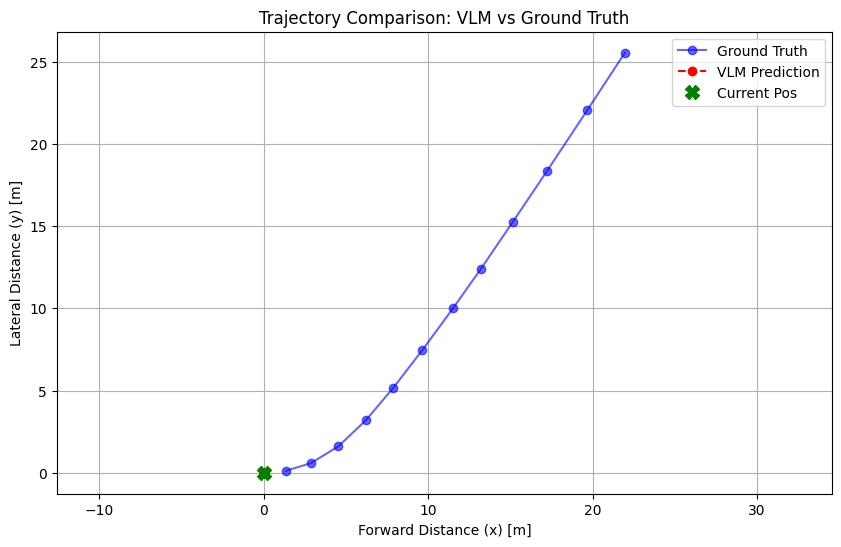

In [17]:
plot_comparison(future_waypoints, output)

In [18]:
future_waypoints

tensor([[ 1.3432,  0.1132,  0.2041],
        [ 2.8805,  0.5921,  0.4424],
        [ 4.5333,  1.6053,  0.6765],
        [ 6.2014,  3.1887,  0.8502],
        [ 7.8839,  5.1797,  0.9031],
        [ 9.6473,  7.4683,  0.9342],
        [11.5153, 10.0136,  0.9534],
        [13.1818, 12.3742,  0.9707],
        [15.1324, 15.2418,  0.9845],
        [17.2191, 18.3461,  0.9902],
        [19.6685, 22.0470,  0.9949],
        [21.9595, 25.5428,  0.9990]])

# Record Data

In [19]:
wp_future = ", ".join([f"({pt[0]:.2f}, {pt[1]:.2f})" for pt in future_waypoints])

data_record = {
    "token": token,
    "wp_past": wp_past,
    "vel_val": vel_val,
    "acc_val": acc_val,
    "yr_val": yr_val,
    "reason": reason,
    "wp_future": wp_future
}

with open('output.jsonl', 'a', encoding='utf-8') as f:
    json.dump(data_record, f, ensure_ascii=False)
    f.write('\n')

print("Record saved to output.jsonl")

Record saved to output.jsonl
